In [2]:

import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split# xtr,xtt,ytr,ytt

from sklearn.metrics import accuracy_score,mean_squared_error, r2_score
#mean_squared_error(y_true,y_pred) r2_score(y_true,y_pred)
from sklearn.metrics import silhouette_score#ss=silhouette_score(x,km.labels_,metric='euclidean')

from sklearn.datasets import load_iris #iris.keys() iris.target iris.data 
from sklearn.datasets import make_blobs#x,y=make_blobs(centers=4,n_features=2,random_state=0)
from sklearn.datasets import load_digits#mnist=load_digits()

from sklearn.cluster import KMeans#km=KMeans(n_clusters=4)

from sklearn.tree import plot_tree as ptr
from sklearn.tree import DecisionTreeClassifier#DTcl=DecisionTreeClassifier(criterion="entropy",max_depth=3).fit(xtr,ytr)
from sklearn import tree# trep=tree.export_text(DTcl)
#fig=plt.figure(figsize(25,20))
#_=tree.plot_tree(DTcl,feature_names=iris.feature_names,class_names=iris.target_names,filled=True)

from sklearn.ensemble import RandomForestRegressor#RandomForestRegressor(n_estimators=200)

import xgboost as xgb#xgb.XGBRegressor(objective='reg:squarederror',n_estimators=200)
from sklearn.neighbors import KNeighborsClassifier as KNN

from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold

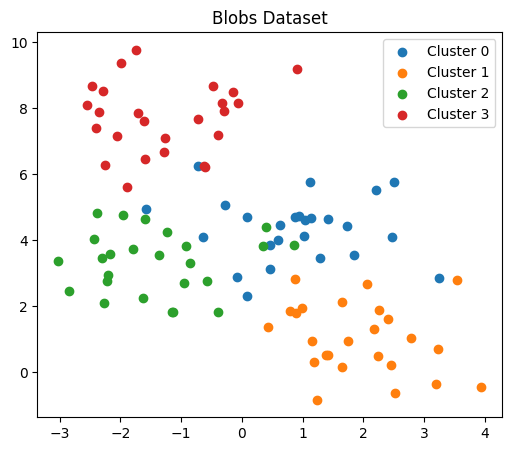

In [ ]:
x,y= make_blobs(centers=4,n_features=2,random_state=0)
#Plotting Blobs
plt.figure(figsize=(6,5))
for label in np.unique(y):
    plt.scatter(
        x[y==label,0],
        x[y==label,1],
        label=f"Cluster {label}"
    )
plt.legend()
plt.title("Blobs Dataset")
plt.show()
knn = KNN()

In [ ]:
param_grid_knn = {#knn
    "n_neighbors":np.arange(1,100,1),
    "weights":["uniform"],
    "metric":['euclidean','manhattan']
}
param_grid_dt = {#decision tree
    "criterion": ["gini", "entropy"],
    "max_depth": [None] + list(range(1, 30)),
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 4, 8],
    "max_leaf_nodes": [None] + list(range(2, 50, 5))
}
param_grid_rf = {#reggressor forest
    "n_estimators": [50, 100, 200, 300],
    "criterion": ["squared_error", "absolute_error"], 
    "max_depth": [None] + list(range(3, 30)),
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
}
param_grid_kmeans = {#kmeans
    "n_clusters": np.arange(2, 15),
    "init": ["k-means++", "random"],
    "n_init": [10, 20, 50]
}
param_grid_logreg = {#logistic regression
    "penalty": ["l1", "l2", "elasticnet", None],
    "C": np.logspace(-4, 4, 20),
}


grid = GridSearchCV(
    estimator=knn,
    param_grid=param_grid_knn,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)



In [ ]:
X_train,y_train,kf = 3,4,5
kvals = np.arange(1,100,1)
avg_val_scores = []
for k in kvals:
    fold_accuracies = []
    model = KNN(n_neighbors=k)


    for train_index, val_index in kf.split(X_train, y_train):
        X_tr, X_val = X_train[train_index], X_train[val_index]
        y_tr, y_val = y_train[train_index], y_train[val_index]

        model.fit(X_tr, y_tr)
        y_pred = model.predict(X_val)
        fold_accuracies. append(accuracy_score(y_val, y_pred))

        avg_acc = np.mean(fold_accuracies)
        avg_val_scores.append(avg_acc)


np_avg_val_scores = np.array(avg_val_scores)
print(np_avg_val_scores)





In [ ]:
data_dict = {'YearsExperience':[],'Salary':[]}
sd = pd.DataFrame.from_dict(data_dict)


from sklearn.metrics import precision_recall_fscore_support#precision_recall_fscore_support(y_true,y_pred)
from sklearn.metrics import f1_score#f1_score(y_true,y_pred)
from sklearn.metrics import classification_report#classification_report(y_true,y_pred)
from sklearn.metrics import confusion_matrix#confusion_matrix(y_true,y_pred)
from sklearn.preprocessing import MinMaxScaler#scaler.fit_transform(x_train) scaler.transform(x_test)
from sklearn.multiclass import OneVsRestClassifier, OneVsOneClassifier
from sklearn.linear_model import LogisticRegression, LinearRegression

clf = OneVsOneClassifier(LogisticRegression())
clf.fit(X_train,y_train)




,YearsExperience,Salary


In [ ]:
labels, counts = np.unique(y, return_counts=True)

plt.bar(labels, counts)
plt.xlabel("Label")
plt.ylabel("Count")
plt.title("Label Distribution")
plt.show()


In [6]:
df = pd.read_table("C:\\Users\\ahmed\\Downloads\\fruit_data.txt")
X = df[df["fruit_name"] == "apple"][["mass", "width", "height"]].values#specific target and specific columns
Z = df[["mass", "width", "height"]].values#specific columns
Y = df[df["fruit_name"]=="apple"][["fruit_name"]].values#specific target
Y = df[df["fruit_name"].isin(["mandarin","apple"])][["fruit_name"]]
Y.head()

,fruit_name
0,apple
1,apple
2,apple
3,mandarin
4,mandarin
